In [1]:
import os
import pandas as pd
import numpy as np
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Load the data (download pre_processing.csv from ".....")

In [2]:
df = pd.read_parquet('datasets/pre_processing.parquet')

Keep data with listings over 11 years

In [3]:
# count number of years per id
obs_per_id = df.groupby(['mun_istat'])['year'].nunique()

# count how many ids have 1 year, 2 years, etc.
count_by_years = obs_per_id.value_counts().sort_index()

print(count_by_years)

year
1        2
2        1
3       21
4        5
5        1
7       38
8        7
9        6
10      21
11    7771
Name: count, dtype: int64


In [4]:
# keep only ids with listings over 11 years - balanced panel data
ids_eleven = obs_per_id[obs_per_id == 11].index

# filter the data
df = df[df['mun_istat'].isin(ids_eleven)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85481 entries, 0 to 86158
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   mun_istat                 85481 non-null  object  
 1   year                      85481 non-null  int64   
 2   mun_name                  85481 non-null  object  
 3   mun_name_norm             85481 non-null  object  
 4   location                  85481 non-null  category
 5   region                    85481 non-null  object  
 6   prov                      85481 non-null  object  
 7   buy_min                   85481 non-null  float64 
 8   buy_max                   85481 non-null  float64 
 9   prov_istat                85481 non-null  object  
 10  population                85481 non-null  float64 
 11  surface                   85481 non-null  float64 
 12  median_income             85481 non-null  float64 
 13  changed                   85481 non-null  bool    


Cumulative data per province (population, dwellings, tourism values)

In [5]:
sum_col = [
    'population', 
    'dwellings', 
    'surface', 
    'five_stars_beds',
    'four_stars_beds',
    'three_stars_beds',
    'two_stars_beds',
    'one_stars_beds',
    'holiday_dwelling_count',
    'holiday_dwelling_beds',
    "tourism_residence_beds",
    "camp_sites_beds",
    "farmhouses_beds",
    "hostels_beds",
    "tourist_dormitories_beds",
    "mountain_huts_beds",
    "bnb_beds",
    'tot_count',
    'tot_acc_beds',
    'tot_beds',
    'tot_arrivals_residents',
    'tot_arrivals_foreigners',
    'tot_arrivals',
    'tot_nights_residents',
    'tot_nights_foreigners',
    'tot_nights']

for col in sum_col:
    df['prov_' + col] = df.groupby(['year', 'prov'], observed=True)[col].transform('sum')

Weighted averages per province (buy_min, buy_max, median_income)

In [6]:
# buy_min * dwellings
df['buy_min_fraction'] = (df['buy_min'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_min_wgt'] = df.groupby(['year','prov'], observed=True)['buy_min_fraction'].transform('sum')

# buy_max * dwellings
df['buy_max_fraction'] = (df['buy_max'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_max_wgt'] = df.groupby(['year','prov'], observed=True)['buy_max_fraction'].transform('sum')

# median_income * population
df['median_income_fraction'] = (df['median_income'] * df['population']) / df['prov_population']
df['prov_median_income_wgt'] = df.groupby(['year','prov'], observed=True)['median_income_fraction'].transform('sum')

# drop fraction cols
df = df.drop(columns = ['buy_min_fraction', 'buy_max_fraction', 'median_income_fraction'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85481 entries, 0 to 86158
Data columns (total 86 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   mun_istat                      85481 non-null  object  
 1   year                           85481 non-null  int64   
 2   mun_name                       85481 non-null  object  
 3   mun_name_norm                  85481 non-null  object  
 4   location                       85481 non-null  category
 5   region                         85481 non-null  object  
 6   prov                           85481 non-null  object  
 7   buy_min                        85481 non-null  float64 
 8   buy_max                        85481 non-null  float64 
 9   prov_istat                     85481 non-null  object  
 10  population                     85481 non-null  float64 
 11  surface                        85481 non-null  float64 
 12  median_income                  85481 

Deflate prices (already deflated) - test correlation

In [8]:
df["price_growth"] = df.groupby("prov")["prov_buy_min_wgt"].pct_change()
df["cpi_growth"] = df["cpi_index"].pct_change()

df[["price_growth", "cpi_growth"]].corr()

,price_growth,cpi_growth
price_growth,1.000000,-0.471601
cpi_growth,-0.471601,1.000000


In [9]:
df_hpi = pd.read_parquet('datasets/macro/hpi.parquet')

In [10]:
df_test = df.groupby(['year'], observed=True).agg({
    'prov_buy_min_wgt':'mean',
    'prov_buy_max_wgt':'mean',
    'cpi_index':'mean'
}).reset_index()

df_test = pd.merge(df_test, df_hpi, on = 'year', how = 'left')

In [11]:
model = smf.ols(formula='hpi ~ prov_buy_min_wgt', data=df_test).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     11.50
Date:                Tue, 27 Jan 2026   Prob (F-statistic):            0.00799
Time:                        10:31:19   Log-Likelihood:                -22.607
No. Observations:                  11   AIC:                             49.21
Df Residuals:                       9   BIC:                             50.01
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.5682     23.612  

Buy avg

In [12]:
df['prov_buy_avg_wgt'] = (df['prov_buy_min_wgt'] + df['prov_buy_max_wgt']) / 2

In [13]:
df['prov_buy_avg_wgt_de'] = (df['prov_buy_avg_wgt'] / df['cpi_index']) * 100

Immigration and emigration ratios

In [14]:
# total number of immigrants and emigrants (standardized per 100 inhabitants) - SEMI-ELASTICITY
df['prov_immigration'] = ((df['abroad_in'] + df['nation_in']) / df['population']) * 100

df['prov_emigration'] = ((df['abroad_out'] + df['nation_out']) / df['population']) * 100

Tourism indexes

In [15]:
# total number of hotel beds
hotel_col = [
    'prov_five_stars_beds',
    'prov_four_stars_beds',
    'prov_three_stars_beds',
    'prov_two_stars_beds',
    'prov_one_stars_beds'
]

df['prov_hotel_beds'] = df[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df = df.drop(columns = hotel_col)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) 
df['prov_ratio_hotel_beds'] = (df['prov_hotel_beds'] / df['prov_population']) * 100

#################################

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and dwellings (per 1000 dwellings) 
df['prov_ratio_str_houses'] = (df['prov_holiday_dwelling_count'] / df['prov_dwellings']) * 1000

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) 
df['prov_ratio_str_beds'] = (df['prov_holiday_dwelling_beds'] / df['prov_population']) * 100

#################################

# OTHER ACCOMODATIONS PRESSURE ON MUNICIPALITY - ratio between other accommodation beds and population (per 100 inhabitants) 
df['prov_other_acc_beds'] = ((df['prov_tot_beds'] - df['prov_hotel_beds'] - df['prov_holiday_dwelling_beds']) / df['prov_population']) * 100

#################################

# measure the ratio between arrivals and population (per 100 inhabitants) 
df['prov_ratio_arrivals_residents'] = (df['prov_tot_arrivals_residents'] / df['prov_population']) * 100

# measure the ratio between foreigner arrivals and population (per 100 inhabitants) 
df['prov_ratio_arrivals_foreigners'] = (df['prov_tot_arrivals_foreigners'] / df['prov_population']) * 100

# measure the ratio between total arrivals and population (per 100 inhabitants) 
df['prov_ratio_tot_arrivals'] = (df['prov_tot_arrivals'] / df['prov_population']) * 100

#################################

# measure the ratio between residents nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights_residents'] = (df['prov_tot_nights_residents'] / df['prov_population']) * 100

# measure the ratio between foreigner nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights_foreigners'] = (df['prov_tot_nights_foreigners'] / df['prov_population']) * 100

# measure the ratio between total nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights'] = (df['prov_tot_nights'] / df['prov_population']) * 100

#################################

# measure the ratio between total beds and population (per 100 inhabitants) - FOR INDEX BRAKE DOWN
df['prov_ratio_tot_beds'] = (df['prov_tot_beds'] / df['prov_population']) * 100

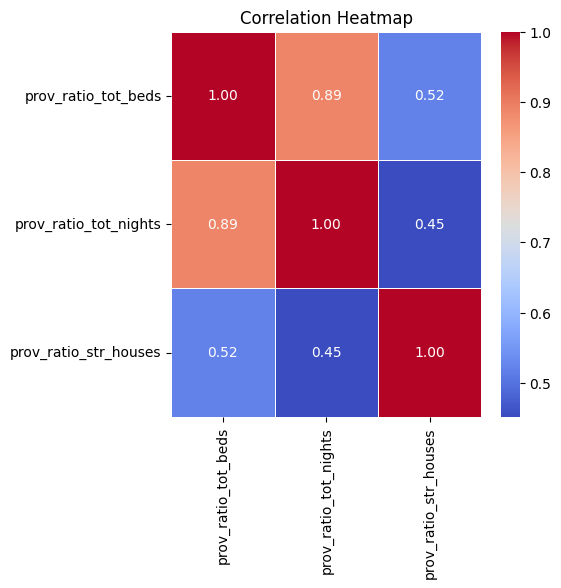

In [16]:
# correlation matrix
var_corr = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

matrix = df[var_corr].corr()

plt.figure(figsize=(5,5))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# compute Van der Waerden score as a tourist index - consider prov_ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vars_tourism = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

df['tourism_index_rnk'] = (
    df
    .groupby('year')[vars_tourism]
    .transform(lambda x: van_der_waerden_score(x))
    .mean(axis=1)
)

df['tourism_index_rnk'].describe()

count    85481.000000
mean        50.000000
std         26.167668
min          1.173014
25%         27.622663
50%         48.513896
75%         71.673958
max         99.002831
Name: tourism_index_rnk, dtype: float64

In [18]:
# compute z-score as a tourist index - consider ratio variables in prov cities
def z_score(x):
    return 100 * (x - x.min()) / (x.max() - x.min())

df['tourism_index_z'] = (
    df
    .groupby('year')[vars_tourism]
    .transform(z_score)
    .mean(axis=1)
)

In [19]:
df['tourism_index_z'].describe()

count    85481.000000
mean        10.548814
std         14.051218
min          0.054902
25%          2.565864
50%          5.766463
75%         11.115989
max         89.149550
Name: tourism_index_z, dtype: float64

Group by province

In [20]:
df_prov = df.groupby(['year','prov'], observed=True).agg({
    'location':'first',
    'region':'first',
    'prov_buy_avg_wgt':'first',
    'prov_buy_avg_wgt_de':'first',
    'prov_buy_min_wgt':'first',
    'prov_buy_max_wgt':'first',
    'prov_median_income_wgt':'first',
    'prov_population':'first',
    'prov_immigration':'first',
    'prov_unemployment':'first',
    'reg_age_avg':'first',
    'prov_ratio_str_houses':'first',
    'prov_ratio_tot_nights' : 'first',
    'prov_ratio_tot_beds' : 'first',
    'tourism_index_rnk':'first',
    'tourism_index_z':'first',
    'tour_employed':'first',
    'real_gdp':'first',
    'cpi_index' : 'first',
    'interest_rate':'first'
}).reset_index()

Log transform

In [21]:
log_col = ['prov_buy_avg_wgt',
           'prov_buy_min_wgt',
           'prov_buy_max_wgt',
           'prov_buy_avg_wgt_de',
           'prov_population',
           'prov_median_income_wgt',
           'prov_immigration',
           'tourism_index_rnk',
           'tourism_index_z',
           'real_gdp',
           'tour_employed',
           'reg_age_avg',
           'prov_unemployment',
           'interest_rate',
           'cpi_index',
           'prov_ratio_str_houses',
           'prov_ratio_tot_nights',
           'prov_ratio_tot_beds']

for col in log_col:
    df_prov['log_' + col] = np.log(df_prov[col] + 1e-6)  # add a small constant to avoid log(0)

Covid dummy

In [22]:
df_prov['covid_all'] = np.where(df_prov['year'].between(2020, 2022), 1, 0)
 
df_prov['covid'] = np.where(df_prov['year'].between(2020, 2021), 1, 0)

df_prov['covid_2020'] = np.where(df_prov['year'] == 2020, 1, 0)

df_prov['covid_2021'] = np.where(df_prov['year'] == 2021, 1, 0)

df_prov['covid_2022'] = np.where(df_prov['year'] == 2022, 1, 0)

Save

In [23]:
df_prov.to_csv('datasets/model.csv', index = False)

Tourist Employment

In [24]:
df_emp = pd.read_parquet('datasets/tourism_employment.parquet')

df_emp['tour_employed'] = df_emp['tour_employed'] / 1000000

Text(0, 0.5, 'People employed in the tourism sector (millions)')

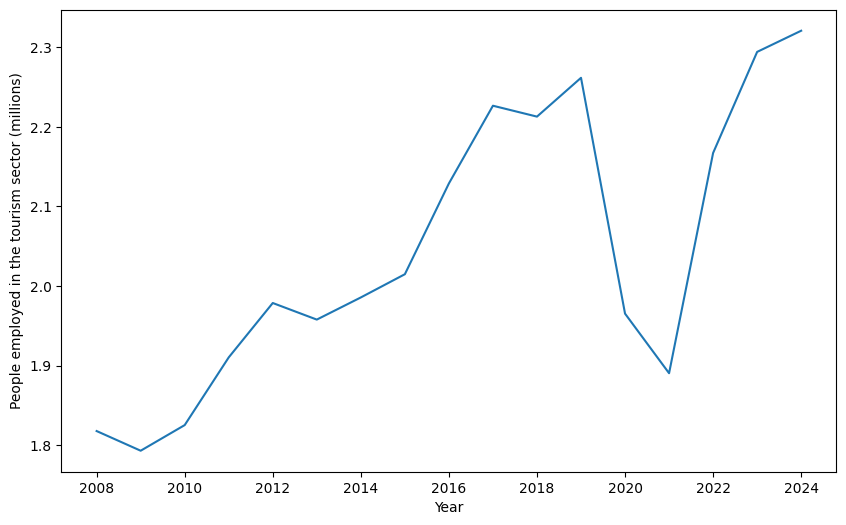

In [25]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_emp, x='year', y='tour_employed')
plt.xlabel('Year')
plt.ylabel('People employed in the tourism sector (millions)')

Tourist arrivals

In [26]:
df_arr = pd.read_csv('datasets/arrivals_2004_2024.csv')

df_arr = df_arr[(df_arr['year'] >= 2008) & (df_arr['year'] <= 2024)]
df_arr['year'] = df_arr['year'].astype(int)

divide = ['residents_arrivals','foreigners_arrivals']
for col in divide:
    df_arr[col] = df_arr[col] / 1000000

Text(0.5, 0, 'Year')

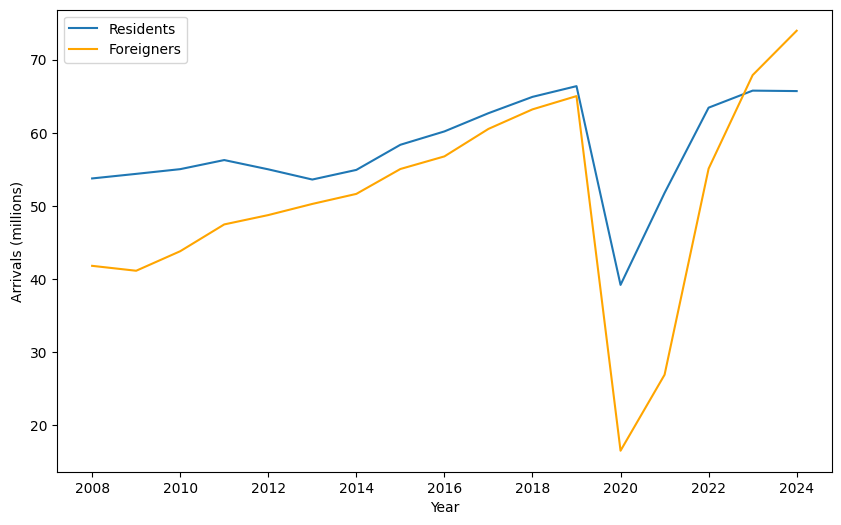

In [27]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_arr, x='year', y='residents_arrivals' , label = 'Residents')
sns.lineplot(data=df_arr, x='year', y='foreigners_arrivals' , color='orange', label = 'Foreigners')
plt.ylabel('Arrivals (millions)')
plt.xlabel('Year')

HPI

Text(0, 0.5, 'Residential Property Price Index')

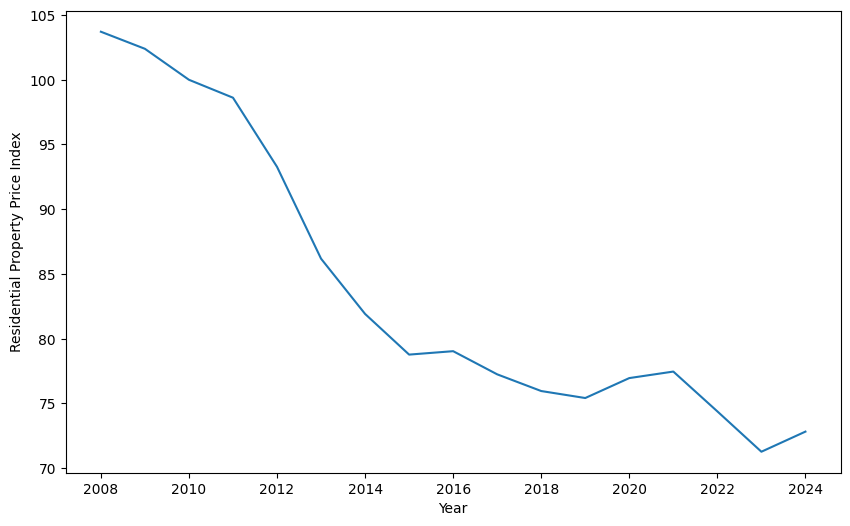

In [28]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_hpi, x= 'year', y = 'hpi')
plt.xlabel('Year')
plt.ylabel('Residential Property Price Index')

Ranking houses

In [29]:
df_2024_h = df_prov[df_prov['year'] == 2024]

ranking_2024_h = (
    df_2024_h
    .sort_values(by='prov_buy_avg_wgt', ascending=False)
    .reset_index(drop=True)
)

ranking_2024_h[['prov', 'year', 'prov_buy_avg_wgt']]

ranking_2024_h[['prov', 'year', 'prov_buy_avg_wgt']].to_excel('datasets/ranking_2024_avg_price.xlsx', index = False)

ranking_2024_h_min = (
    df_2024_h
    .sort_values(by='prov_buy_min_wgt', ascending=False)
    .reset_index(drop=True)
)

ranking_2024_h_min[['prov', 'year', 'prov_buy_min_wgt']]

ranking_2024_h_min[['prov', 'year', 'prov_buy_min_wgt']].to_excel('datasets/ranking_2024_min_price.xlsx', index = False)


ranking_2024_h_max = (
    df_2024_h
    .sort_values(by='prov_buy_max_wgt', ascending=False)
    .reset_index(drop=True)
)

ranking_2024_h_max[['prov', 'year', 'prov_buy_max_wgt']]

ranking_2024_h_max[['prov', 'year', 'prov_buy_max_wgt']].to_excel('datasets/ranking_2024_max_price.xlsx', index = False)

In [30]:
df_prov['rank_min'] = df_prov.groupby('year')['prov_buy_min_wgt'].rank()
df_prov['rank_max'] = df_prov.groupby('year')['prov_buy_max_wgt'].rank()

df_prov[['rank_min', 'rank_max']].corr()

,rank_min,rank_max
rank_min,1.000000,0.985903
rank_max,0.985903,1.000000


In [31]:
df_prov[[
    'prov_buy_avg_wgt',
    'prov_buy_min_wgt',
    'prov_buy_max_wgt',
    'tourism_index_rnk',
    'tourism_index_z',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses',
    'prov_population',
    'reg_age_avg',
    'prov_immigration',
    'prov_median_income_wgt',
    'prov_unemployment',
    'real_gdp',
    'interest_rate',
    'cpi_index'
]].describe()

,prov_buy_avg_wgt,prov_buy_min_wgt,prov_buy_max_wgt,tourism_index_rnk,tourism_index_z,prov_ratio_tot_nights,prov_ratio_str_houses,prov_population,reg_age_avg,prov_immigration,prov_median_income_wgt,prov_unemployment,real_gdp,interest_rate,cpi_index
count,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1.210000e+03,1210.000000,1210.000000,1210.000000,1210.000000,1.210000e+03,1210.000000,1210.000000
mean,1278.696545,1087.955065,1469.438026,54.179606,12.193410,729.343855,2.949493,5.383175e+05,45.770521,472.830863,15576.901971,10.383388,1.616458e+06,2.384798,106.563636
std,519.413086,445.899247,596.106876,26.820234,15.026784,951.329324,7.509791,5.943572e+05,2.083010,849.737950,2729.064011,5.690805,6.912378e+04,0.869693,8.060206
min,519.593264,430.069936,609.116593,1.173014,0.054902,15.759942,0.000000,5.165400e+04,40.169304,3.942133,9294.967415,1.600000,1.483850e+06,1.320925,99.900000
25%,894.100961,746.261368,1035.329072,31.086486,2.774818,174.367868,0.414214,2.259792e+05,44.474184,69.928674,13189.646580,6.200000,1.563290e+06,1.691567,100.000000
50%,1176.404680,1021.698371,1326.087696,56.527706,6.938369,398.746145,0.887519,3.688475e+05,45.665030,175.312492,15826.184240,8.700000,1.616373e+06,2.139983,103.000000
75%,1520.323105,1308.156572,1729.387501,77.368009,14.906672,842.278179,2.263898,5.869380e+05,46.878978,476.007391,17984.088327,13.600000,1.694301e+06,3.185883,114.200000
max,3133.049590,2726.387063,3539.712118,99.002831,89.149550,6904.184731,79.225957,4.141267e+06,61.968029,7095.597484,21384.856438,31.500000,1.722683e+06,4.164800,122.300000


Text(0, 0.5, 'Z-score Tourism Index')

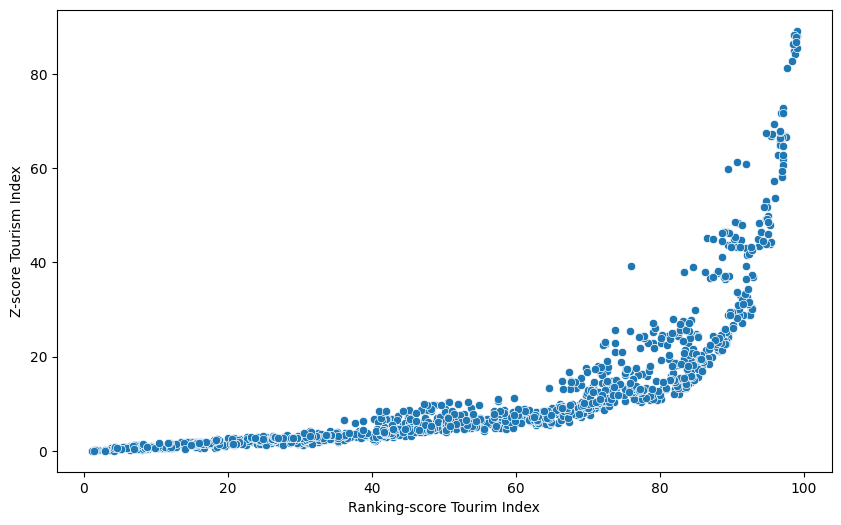

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_prov, x='tourism_index_rnk', y='tourism_index_z')
plt.xlabel('Ranking-score Tourim Index')
plt.ylabel('Z-score Tourism Index')

In [33]:
df_prov['rank_vdw'] = df_prov.groupby('year')['tourism_index_rnk'].rank()
df_prov['rank_z'] = df_prov.groupby('year')['tourism_index_z'].rank()

df_prov[['rank_vdw', 'rank_z']].corr()

,rank_vdw,rank_z
rank_vdw,1.000000,0.975558
rank_z,0.975558,1.000000


In [34]:
df_2024 = df_prov[df_prov['year'] == 2024]

ranking_2024 = (
    df_2024
    .sort_values(by='tourism_index_rnk', ascending=False)
    .reset_index(drop=True)
)

print(ranking_2024[['prov', 'year', 'tourism_index_rnk']])


ranking_2024 = (
    df_2024
    .sort_values(by='tourism_index_z', ascending=False)
    .reset_index(drop=True)
)

print(ranking_2024[['prov', 'year', 'tourism_index_z']])

    prov  year  tourism_index_rnk
0     VE  2024          98.895608
1     BZ  2024          97.096414
2     RN  2024          95.835478
3     BL  2024          95.337965
4     GR  2024          94.996998
..   ...   ...                ...
105   MB  2024           6.926574
106   EN  2024           6.821496
107   CL  2024           4.689913
108   AV  2024           4.393978
109   LO  2024           1.490393

[110 rows x 3 columns]
    prov  year  tourism_index_z
0     VE  2024        86.829561
1     BZ  2024        71.602115
2     RN  2024        57.334541
3     OT  2024        51.805187
4     GR  2024        48.629386
..   ...   ...              ...
105   AV  2024         0.797287
106   CR  2024         0.758402
107   CL  2024         0.612100
108   MB  2024         0.494053
109   LO  2024         0.083392

[110 rows x 3 columns]
